# Statistics

## Parameters

In [1]:
g = 2.1
n = 1000
b = 2.1
k = 20
m = int(k/2)
p = k/(n-1)
seed = 12349


working_folder = f'./statistics-nets'
s1h2_working_folder = f'{working_folder}'
er_working_folder = f'{working_folder}'
ba_working_folder = f'{working_folder}'
conf_working_folder = f'{working_folder}'

er_file = f'{working_folder}/er-n={n}-k={k}-s={seed}'
ba_file = f'{working_folder}/ba-n={n}-k={k}-s={seed}'
conf_file = f'{working_folder}/conf-n={n}-k={k}-g={g}-s={seed}'
s1h2_file = f'{working_folder}/s1h2-n={n}-k={k}-g={g}-b={b}-s={seed}'

er_edges_file = f'{er_file}.edge'
ba_edges_file = f'{ba_file}.edge'
conf_edges_file = f'{conf_file}.edge'
s1h2_edges_file = f'{s1h2_file}.edge'


er_coords_file = f'{er_file}.inf_coord'
ba_coords_file = f'{ba_file}.inf_coord'
conf_coords_file = f'{conf_file}.inf_coord'
s1h2_coords_file = f'{s1h2_file}.inf_coord'

## Generation

In [ ]:
import re
import networkx as nx
from pathlib import Path
def generate_powerlaw_sequence_with_avg_k(n, gamma, target_k, k_max=100, tolerance=0.1, seed=12345):
    """
    Genera una secuencia de grados con γ fijo que se aproxime a <k> objetivo.
    """
    import numpy as np
    # Buscar k_min que dé el <k> deseado
    k_min = 1
    best_seq = None
    best_avg = 0
    rng = np.random.RandomState(seed)
    for k_min_candidate in range(1, 20):
        # Generar grados con este k_min
        degrees = []
        while len(degrees) < n:
            # Muestreo por transformada inversa
            r = rng.random()
            k = k_min_candidate * (1 - r) ** (-1/(gamma-1))
            if k <= k_max:
                degrees.append(int(np.floor(k)))
        
        # Ajustar para que la suma sea par (requisito del modelo de configuración)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1
        
        current_avg = np.mean(degrees)
        
        if abs(current_avg - target_k) < abs(best_avg - target_k):
            best_avg = current_avg
            best_seq = degrees
        
        if abs(current_avg - target_k) < tolerance:
            return degrees
    
    return best_seq

Gba = nx.barabasi_albert_graph(n, m, seed=seed)
sequence = generate_powerlaw_sequence_with_avg_k(n, gamma=g, target_k=k, seed=seed, tolerance=0.001)
Gconf = nx.configuration_model(sequence)
Ger = nx.erdos_renyi_graph(n, p, seed=seed)

! mkdir -p {s1h2_working_folder}
! mkdir -p {er_working_folder}
! mkdir -p {ba_working_folder}
! mkdir -p {conf_working_folder}

nx.write_edgelist(Gba, ba_edges_file, data=False)
nx.write_edgelist(Ger, er_edges_file, data=False)
nx.write_edgelist(Gconf, conf_edges_file, data=False)
! ./tools/genSD -d 1 -n {n} -g {g} -k {k} -b {b} -s {seed} -o {s1h2_file}
# remove v from node name
t = Path(s1h2_edges_file).read_text()
t = re.sub(r'v(\d)', r'\1', t)
Path(s1h2_edges_file).write_text(t)

Gs1h2 = nx.read_edgelist(s1h2_edges_file)

## Read

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import powerlaw

# Lista de archivos (ajusta la ruta)
archivos = glob("./statistics-nets/conf*.edge")   # o .edges, .csv, etc.

def leer_grafo(archivo):
    # Si es edge list con dos columnas sin cabecera
    return nx.read_edgelist(archivo, nodetype=int)  # o str según tus nodos

In [3]:
def metricas_red(G):
    N = G.number_of_nodes()
    E = G.number_of_edges()
    densidad = nx.density(G)
    clustering_prom = nx.average_clustering(G)
    transitividad = nx.transitivity(G)
    grados = [d for n, d in G.degree()]
    
    # Componente gigante para distancias
    if nx.is_connected(G):
        avg_path = nx.average_shortest_path_length(G)
        diametro = nx.diameter(G)
    else:
        giant = max(nx.connected_components(G), key=len)
        G_giant = G.subgraph(giant)
        avg_path = nx.average_shortest_path_length(G_giant)
        diametro = nx.diameter(G_giant)
        
    assortativity = nx.degree_assortativity_coefficient(G)
    
    return {
        'N': N, 'E': E, 'densidad': densidad,
        'clustering_prom': clustering_prom,
        'transitividad': transitividad,
        'avg_path_length': avg_path,
        'diametro': diametro,
        'assortativity': assortativity,
        'grados': grados
    }
def plot_degree_distribution(grados, ax=None, label='Red'):
    from collections import Counter
    cont = Counter(grados)
    k, pk = zip(*sorted(cont.items()))
    pk = np.array(pk) / sum(pk)
    ax = ax or plt.gca()
    ax.loglog(k, pk, 'o', label=label)
    ax.set_xlabel('Grado k')
    ax.set_ylabel('P(k)')
    ax.grid(True)

def fit_powerlaw(grados):
    # Eliminar grado cero (si lo hay)
    grados = [g for g in grados if g > 0]
    fit = powerlaw.Fit(grados, discrete=True)
    print(f"Exponente gamma: {fit.power_law.alpha:.3f}")
    print(f"k_min: {fit.power_law.xmin}")
    print(f"p-valor (KS): {fit.power_law.KS()}")
    return fit

In [4]:
resultados = []
for archivo in archivos:
    G = leer_grafo(archivo)
    stats = metricas_red(G)
    stats['archivo'] = archivo
    resultados.append(stats)

df = pd.DataFrame(resultados)
# Promedio y desviación (ignorando columna 'grados' y 'archivo')
metricas_promedio = df.drop(columns=['archivo','grados']).mean()
metricas_std = df.drop(columns=['archivo','grados']).std()

print("=== Métricas promedio ± desviación ===")
for m in metricas_promedio.index:
    print(f"{m}: {metricas_promedio[m]:.4f} ± {metricas_std[m]:.4f}")

=== Métricas promedio ± desviación ===
N: 1000.0000 ± 0.0000
E: 9861.6000 ± 450.2281
densidad: 0.0197 ± 0.0009
clustering_prom: 0.0519 ± 0.0041
transitividad: 0.0500 ± 0.0043
avg_path_length: 2.5976 ± 0.0224
diametro: 4.0000 ± 0.0000
assortativity: -0.0207 ± 0.0110


N         1000.000000
E         9900.000000
clust        0.059711
trans        0.053740
L            2.558167
diam         4.000000
assort      -0.030652 N         0.000000
E         0.000000
clust     0.001615
trans     0.000828
L         0.002001
diam      0.000000
assort    0.002926


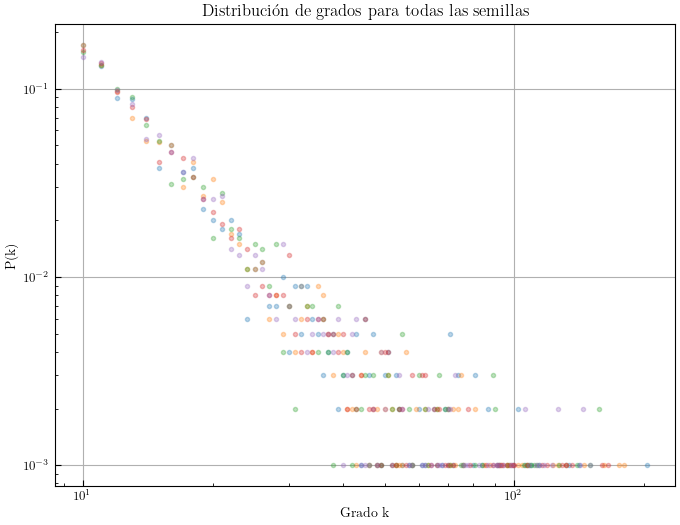

Gamma = 2.822, k_min = 10.0


Calculating best minimal value for power law fit
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


In [8]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from collections import Counter
import powerlaw
import pipeline.init as init

init.configure_matplotlib()


# --- Configuración
archivos = sorted(glob("./statistics-nets/ba*.edge"))
resultados = []

for archivo in archivos:
    G = nx.read_edgelist(archivo, nodetype=int)
    N = G.number_of_nodes()
    E = G.number_of_edges()
    clust = nx.average_clustering(G)
    trans = nx.transitivity(G)
    grados = [d for n,d in G.degree()]
    
    # Longitud media
    if nx.is_connected(G):
        L = nx.average_shortest_path_length(G)
        diam = nx.diameter(G)
    else:
        giant = max(nx.connected_components(G), key=len)
        Gc = G.subgraph(giant)
        L = nx.average_shortest_path_length(Gc)
        diam = nx.diameter(Gc)
    
    assort = nx.degree_assortativity_coefficient(G)
    
    resultados.append({
        'file': archivo,
        'N': N, 'E': E, 'clust': clust, 'trans': trans,
        'L': L, 'diam': diam, 'assort': assort,
        'grados': grados
    })

# --- Análisis agregado
df = pd.DataFrame(resultados)
promedios = df[['N','E','clust','trans','L','diam','assort']].mean()
desv = df[['N','E','clust','trans','L','diam','assort']].std()
print(promedios.to_string(), desv.to_string())

# --- Figura: distribución de grados (todas las semillas en un mismo gráfico)
plt.figure(figsize=(8,6))
for i, row in df.iterrows():
    cont = Counter(row['grados'])
    k, pk = zip(*sorted(cont.items()))
    pk = np.array(pk) / sum(pk)
    plt.loglog(k, pk, 'o', alpha=0.3, markersize=3)
plt.xlabel('Grado k'); plt.ylabel('P(k)')
plt.title('Distribución de grados para todas las semillas')
plt.grid(True)
plt.savefig('degree_distributions.pdf')
plt.show()

# --- Ajuste de power law para la primera red (ejemplo)
grados_primera = df.iloc[0]['grados']
grados_primera = [g for g in grados_primera if g>0]
fit = powerlaw.Fit(grados_primera, discrete=True)
print(f"Gamma = {fit.power_law.alpha:.3f}, k_min = {fit.power_law.xmin}")


Procesando tipo: s1h2


/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


  Semillas procesadas: 5
  N = 996.8 ± 2.4
  <k> = 15.89 ± 2.63
  gamma medio = 2.22 ± 0.07

Procesando tipo: ba


/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


  Semillas procesadas: 5
  N = 1000.0 ± 0.0
  <k> = 19.80 ± 0.00
  gamma medio = 2.83 ± 0.02

Procesando tipo: er


/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


  Semillas procesadas: 5
  N = 1000.0 ± 0.0
  <k> = 20.16 ± 0.25
  gamma medio = 9.27 ± 0.85

Procesando tipo: conf


/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


  Semillas procesadas: 5
  N = 1000.0 ± 0.0
  <k> = 19.72 ± 0.90
  gamma medio = 2.40 ± 0.27


=== Código LaTeX de la tabla ===

\begin{tabular}{lllllllllll}
\toprule
Tipo & $N$ & $E$ & Densidad & $\langle k \rangle$ & Clustering & Transitividad & $\ell$ & Diámetro & Asortatividad & $\gamma$ \\
\midrule
s1h2 & 996 $\pm$ 2 & 7922 $\pm$ 1323 & 0.016 $\pm$ 0.003 & 15.892 $\pm$ 2.633 & 0.647 $\pm$ 0.045 & 0.143 $\pm$ 0.021 & 2.481 $\pm$ 0.183 & 5 $\pm$ 0 & -0.235 $\pm$ 0.043 & 2.224 $\pm$ 0.071 \\
ba & 1000 $\pm$ 0 & 9900 $\pm$ 0 & 0.020 $\pm$ 0.000 & 19.800 $\pm$ 0.000 & 0.060 $\pm$ 0.002 & 0.054 $\pm$ 0.001 & 2.558 $\pm$ 0.002 & 4 $\pm$ 0 & -0.031 $\pm$ 0.003 & 2.826 $\pm$ 0.018 \\
er & 1000 $\pm$ 0 & 10079 $\pm$ 123 & 0.020 $\pm$ 0.000 & 20.158 $\pm$ 0.248 & 0.020 $\pm$ 0.000 & 0.020 $\pm$ 0.001 & 2.634 $\pm$ 0.007 & 4 $\pm$ 0 & -0.004 $\pm$ 0.006 & 9.268 $\pm$ 0.853 \\
conf & 1000 $\pm$ 0 & 9861 $\pm$ 450 & 0.020 $\pm$ 0.001 & 19.723 $\pm$ 0.900 & 0.052 $\pm$ 0.004 & 0.050 $\pm$ 0.004 

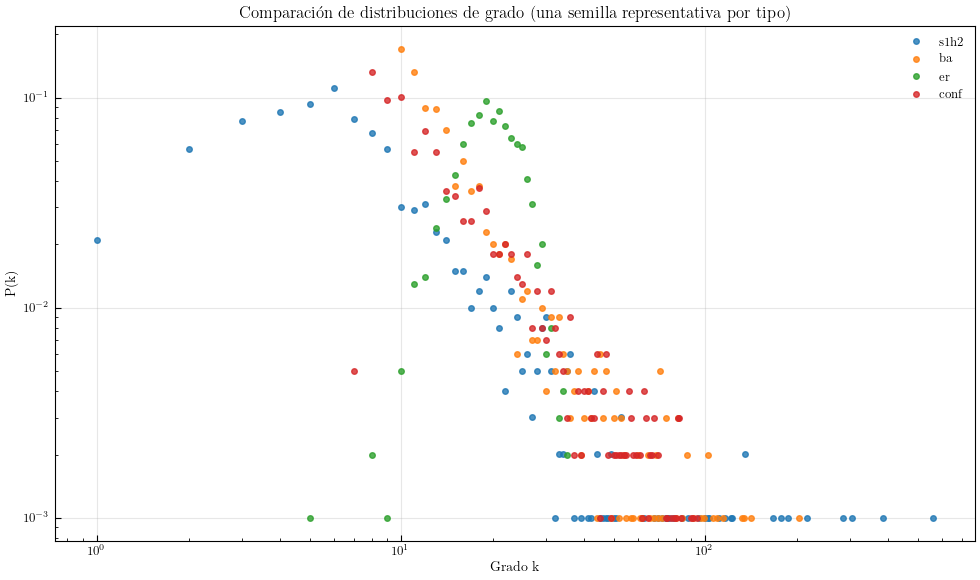

/tmp/ipykernel_12702/4095334176.py:205: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=etiq)
/tmp/ipykernel_12702/4095334176.py:205: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=etiq)
/tmp/ipykernel_12702/4095334176.py:205: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=etiq)
/tmp/ipykernel_12702/4095334176.py:205: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=etiq)


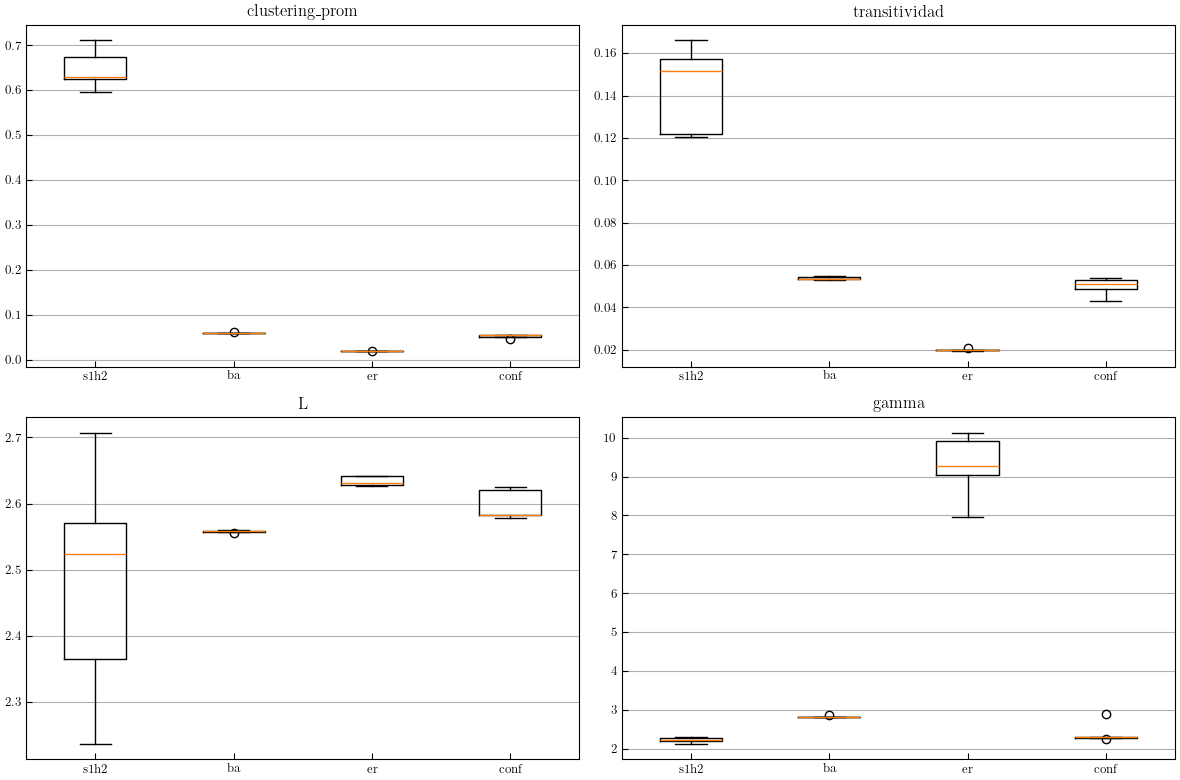

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import powerlaw   # pip install powerlaw

import pipeline.init as init

init.configure_matplotlib()
# ------------------------------------------------------------
# Configuración
# ------------------------------------------------------------
tipos = ['s1h2', 'ba', 'er', 'conf']   # añade el quinto si falta
ruta_base = "data"
extension = ".edges"   # o .txt, .csv

# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------
def leer_grafo(archivo):
    """Lee edge list (dos columnas sin cabecera, nodos enteros)"""
    return nx.read_edgelist(archivo, nodetype=int)

def metricas_red(G):
    """Calcula métricas básicas de una red G (no dirigida)"""
    N = G.number_of_nodes()
    E = G.number_of_edges()
    densidad = nx.density(G)
    clustering_prom = nx.average_clustering(G)
    transitividad = nx.transitivity(G)
    grados = [d for n,d in G.degree()]
    grado_medio = np.mean(grados)
    
    # Para caminos: usar componente gigante si es disconexa
    if nx.is_connected(G):
        L = nx.average_shortest_path_length(G)
        diam = nx.diameter(G)
    else:
        giant = max(nx.connected_components(G), key=len)
        G_giant = G.subgraph(giant)
        L = nx.average_shortest_path_length(G_giant)
        diam = nx.diameter(G_giant)
    
    assort = nx.degree_assortativity_coefficient(G)
    
    return {
        'N': N, 'E': E, 'densidad': densidad,
        'grado_medio': grado_medio,
        'clustering_prom': clustering_prom,
        'transitividad': transitividad,
        'L': L, 'diametro': diam,
        'assortativity': assort,
        'grados': grados
    }

def ajuste_powerlaw(grados, print_info=False):
    """Ajusta ley de potencia a la distribución de grados (excluye grado 0)"""
    grados_pos = [g for g in grados if g > 0]
    if len(grados_pos) < 10:
        return np.nan, np.nan, np.nan
    fit = powerlaw.Fit(grados_pos, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    xmin = fit.power_law.xmin
    p = fit.power_law.KS()  # p-valor de KS
    if print_info:
        print(f"  gamma = {gamma:.3f}, k_min = {xmin}, p(KS) = {p:.3f}")
    return gamma, xmin, p

def plot_degree_distributions(todas_listas, etiquetas, alpha=0.5, bins=None, ax=None, loglog=True):
    """Dibuja las distribuciones de grado de varios conjuntos en un mismo gráfico.
       todas_listas: lista de listas de grados (una por tipo o semilla)
       etiquetas: lista de nombres (misma longitud)
    """
    ax = ax or plt.gca()
    for grados, label in zip(todas_listas, etiquetas):
        cont = Counter(grados)
        ks = np.array(sorted(cont.keys()))
        ps = np.array([cont[k] for k in ks]) / len(grados)
        if loglog:
            ax.loglog(ks, ps, 'o', alpha=alpha, markersize=4, label=label)
        else:
            ax.plot(ks, ps, 'o', alpha=alpha, markersize=4, label=label)
    ax.set_xlabel("Grado k")
    ax.set_ylabel("P(k)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    return ax

# ------------------------------------------------------------
# Procesamiento principal
# ------------------------------------------------------------
resultados_por_tipo = {}   # guarda cada DataFrame de métricas por tipo

for tipo in tipos:
    print(f"\nProcesando tipo: {tipo}")
    patron = f"*statistics-nets/{tipo}*"
    archivos = sorted(glob.glob(patron))
    if not archivos:
        print(f"  ¡No se encontraron archivos para {tipo}!")
        continue
    
    lista_metricas = []
    lista_grados = []   # para luego combinar todas las semillas si quieres
    
    for arch in archivos:
        G = leer_grafo(arch)
        stats = metricas_red(G)
        # Añadir ajuste power law
        gamma, xmin, p_ks = ajuste_powerlaw(stats['grados'])
        stats['gamma'] = gamma
        stats['xmin'] = xmin
        stats['p_KS'] = p_ks
        stats['archivo'] = os.path.basename(arch)
        lista_metricas.append(stats)
        lista_grados.append(stats['grados'])
    
    df_tipo = pd.DataFrame(lista_metricas)
    resultados_por_tipo[tipo] = df_tipo
    
    # Guardar CSV por tipo (opcional)
    df_tipo.to_csv(f"resultados_{tipo}.csv", index=False)
    
    # Resumen rápido por tipo
    print(f"  Semillas procesadas: {len(archivos)}")
    print(f"  N = {df_tipo['N'].mean():.1f} ± {df_tipo['N'].std():.1f}")
    print(f"  <k> = {df_tipo['grado_medio'].mean():.2f} ± {df_tipo['grado_medio'].std():.2f}")
    print(f"  gamma medio = {df_tipo['gamma'].mean():.2f} ± {df_tipo['gamma'].std():.2f}")

# ------------------------------------------------------------
# Tabla LaTeX con promedios y desviaciones
# ------------------------------------------------------------
# Seleccionamos columnas numéricas de interés
columnas_interes = ['N', 'E', 'densidad', 'grado_medio', 
                    'clustering_prom', 'transitividad', 
                    'L', 'diametro', 'assortativity', 'gamma']

filas = []
for tipo, df in resultados_por_tipo.items():
    fila = [tipo]
    for col in columnas_interes:
        media = df[col].mean()
        std = df[col].std()
        if col in ['N', 'E', 'diametro']:   # enteros
            fila.append(f"{int(media):d} $\\pm$ {int(std):d}")
        else:
            fila.append(f"{media:.3f} $\\pm$ {std:.3f}")
    filas.append(fila)

# Crear DataFrame para LaTeX
tabla_df = pd.DataFrame(filas, columns=['Tipo'] + columnas_interes)
# Ajustar nombres de columnas para LaTeX
tabla_df.columns = ['Tipo', '$N$', '$E$', 'Densidad', '$\\langle k \\rangle$',
                    'Clustering', 'Transitividad', '$\\ell$', 'Diámetro',
                    'Asortatividad', '$\\gamma$']

# Generar código LaTeX
latex_code = tabla_df.to_latex(index=False, escape=False, float_format="%.3f")
# Corregir el símbolo \pm (ya lo pusimos manualmente con $\\pm$)
# Como ya tenemos el texto con $\pm$, to_latex no lo interpreta mal.
print("\n\n=== Código LaTeX de la tabla ===\n")
print(latex_code)

# Guardar a un archivo .tex
with open("tabla_redes.tex", "w") as f:
    f.write(latex_code)

# ------------------------------------------------------------
# Figura comparativa de distribuciones de grado
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
# Elegimos, por ejemplo, la primera semilla de cada tipo para no saturar
# (o promediar las distribuciones, pero es más complejo).
# Para una comparación clara, puedes mostrar todas las semillas de cada tipo con transparencia,
# o bien mostrar una curva por tipo (el promedio de las CCDF).
# Aquí haremos una curva por tipo usando la primera semilla (representativa).

todas_listas = []
etiquetas = []
for tipo in tipos:
    df = resultados_por_tipo.get(tipo)
    if df is not None and len(df) > 0:
        # Usamos la primera semilla (puedes cambiar por la que tenga mediana N)
        grados_ejemplo = df.iloc[0]['grados']
        todas_listas.append(grados_ejemplo)
        etiquetas.append(tipo)

plot_degree_distributions(todas_listas, etiquetas, alpha=0.8, loglog=True)
plt.title("Comparación de distribuciones de grado (una semilla representativa por tipo)")
plt.tight_layout()
plt.savefig("comparacion_degree_distributions.pdf", dpi=150)
plt.show()

# ------------------------------------------------------------
# (Opcional) Boxplots de métricas clave por tipo
# ------------------------------------------------------------
metricas_box = ['clustering_prom', 'transitividad', 'L', 'gamma']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, met in zip(axes, metricas_box):
    datos = [resultados_por_tipo[t][met].dropna() for t in tipos if t in resultados_por_tipo]
    etiq = [t for t in tipos if t in resultados_por_tipo]
    ax.boxplot(datos, labels=etiq)
    ax.set_title(met)
    ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig("boxplots_metricas.pdf")
plt.show()


Procesando s1h2...


/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


  Semillas: 5
  N = 996.8 ± 2.4
  gamma = 2.22 ± 0.07

Procesando ba...
  Semillas: 5
  N = 1000.0 ± 0.0
  gamma = 2.83 ± 0.02

Procesando er...
  Semillas: 5
  N = 1000.0 ± 0.0
  gamma = 9.27 ± 0.85

Procesando conf...
  Semillas: 5
  N = 1000.0 ± 0.0
  gamma = 2.40 ± 0.27

Procesando custom...
  No se encontraron archivos para custom -> omitido.


=== Tabla LaTeX para doble columna ===

\begin{table*}[t]
\centering
\caption{Métricas promedio de las redes.}
\begin{tabular}{lllllll}
\toprule
Tipo & $N$ & $\langle k \rangle$ & $C$ & $\ell$ & $\gamma$ & $r$ \\
\midrule
s1h2 & 996 $\pm$ 2 & 15.892 $\pm$ 2.633 & 0.647 $\pm$ 0.045 & 2.481 $\pm$ 0.183 & 2.224 $\pm$ 0.071 & -0.235 $\pm$ 0.043 \\
ba & 1000 $\pm$ 0 & 19.800 $\pm$ 0.000 & 0.060 $\pm$ 0.002 & 2.558 $\pm$ 0.002 & 2.826 $\pm$ 0.018 & -0.031 $\pm$ 0.003 \\
er & 1000 $\pm$ 0 & 20.158 $\pm$ 0.248 & 0.020 $\pm$ 0.000 & 2.634 $\pm$ 0.007 & 9.268 $\pm$ 0.853 & -0.004 $\pm$ 0.006 \\
conf & 1000 $\pm$ 0 & 19.723 $\pm$ 0.900 & 0.052 $\pm$ 0

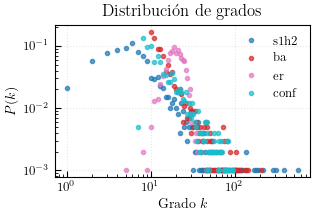

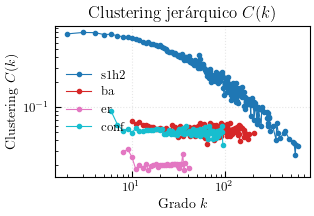

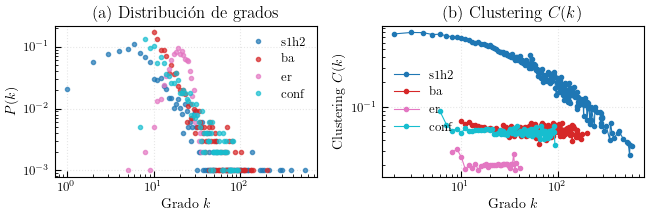

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import powerlaw
from scipy.interpolate import interp1d
import pipeline.init as init 
# ------------------------------------------------------------
# Configuración de estilo académico
# ------------------------------------------------------------
init.configure_matplotlib()
# ------------------------------------------------------------
# Rutas y tipos (cambiar según tu caso)
# ------------------------------------------------------------
tipos = ['s1h2', 'ba', 'er', 'conf', 'custom']   # 5 tipos
ruta_base = "data"
extension = ".edges"

# ------------------------------------------------------------
# Funciones de análisis
# ------------------------------------------------------------
def leer_grafo(archivo):
    return nx.read_edgelist(archivo, nodetype=int)

def metricas_red(G):
    N = G.number_of_nodes()
    E = G.number_of_edges()
    grado_medio = np.mean([d for n,d in G.degree()])
    clustering_prom = nx.average_clustering(G)
    transitividad = nx.transitivity(G)
    # Longitud media (componente gigante)
    if nx.is_connected(G):
        L = nx.average_shortest_path_length(G)
        diam = nx.diameter(G)
    else:
        giant = max(nx.connected_components(G), key=len)
        G_giant = G.subgraph(giant)
        L = nx.average_shortest_path_length(G_giant)
        diam = nx.diameter(G_giant)
    assort = nx.degree_assortativity_coefficient(G)
    grados = [d for n,d in G.degree()]
    # C(k)
    k_vals, c_mean, c_std = clustering_by_degree(G)
    return {
        'N': N, 'E': E, 'grado_medio': grado_medio,
        'clustering_prom': clustering_prom,
        'transitividad': transitividad,
        'L': L, 'diametro': diam, 'assortativity': assort,
        'grados': grados,
        'ck_vals': k_vals,
        'ck_mean': c_mean,
        'ck_std': c_std
    }

def clustering_by_degree(G):
    k_to_clust = defaultdict(list)
    for node in G.nodes():
        k = G.degree(node)
        clust = nx.clustering(G, node)
        k_to_clust[k].append(clust)
    ks = sorted(k_to_clust.keys())
    means = [np.mean(k_to_clust[k]) for k in ks]
    stds = [np.std(k_to_clust[k]) if len(k_to_clust[k])>1 else 0 for k in ks]
    return ks, means, stds

def ajuste_powerlaw(grados, print_info=False):
    grados_pos = [g for g in grados if g > 0]
    if len(grados_pos) < 10:
        return np.nan, np.nan, np.nan
    fit = powerlaw.Fit(grados_pos, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    xmin = fit.power_law.xmin
    p = fit.power_law.KS()
    if print_info:
        print(f"gamma={gamma:.3f}, xmin={xmin}, p={p:.3f}")
    return gamma, xmin, p

def plot_degree_distribution_clean(grados_list, etiquetas, ax=None, loglog=True, colors=None):
    """Dibuja P(k) con formato académico."""
    if ax is None:
        ax = plt.gca()
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0,1,len(etiquetas)))
    for i, (grados, label) in enumerate(zip(grados_list, etiquetas)):
        cont = Counter(grados)
        ks = np.array(sorted(cont.keys()))
        ps = np.array([cont[k] for k in ks]) / len(grados)
        if loglog:
            ax.loglog(ks, ps, 'o', color=colors[i], alpha=0.7, markersize=3, label=label)
        else:
            ax.plot(ks, ps, 'o', color=colors[i], alpha=0.7, markersize=3, label=label)
    ax.set_xlabel(r'Grado $k$')
    ax.set_ylabel(r'$P(k)$')
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(frameon=False, loc='best')
    return ax

def plot_ck_curves(ck_data, etiquetas, ax=None, loglog=True):
    """ck_data: lista de tuplas (k_vals, c_mean, c_std) por tipo"""
    if ax is None:
        ax = plt.gca()
    colors = plt.cm.tab10(np.linspace(0,1,len(etiquetas)))
    for i, (k_vals, c_mean, c_std) in enumerate(ck_data):
        k_vals = np.array(k_vals)
        c_mean = np.array(c_mean)
        # Evitar ceros para loglog
        mask = (c_mean > 0) & (k_vals > 0)
        if loglog:
            ax.loglog(k_vals[mask], c_mean[mask], 'o-', color=colors[i], 
                      markersize=3, linewidth=0.8, label=etiquetas[i])
            # Banda de desviación (opcional, a veces satura)
            # ax.fill_between(k_vals[mask], c_mean[mask]-c_std[mask], c_mean[mask]+c_std[mask],
            #                  color=colors[i], alpha=0.2)
        else:
            ax.plot(k_vals[mask], c_mean[mask], 'o-', color=colors[i], label=etiquetas[i])
    ax.set_xlabel(r'Grado $k$')
    ax.set_ylabel(r'Clustering $C(k)$')
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(frameon=False, loc='best')
    return ax

# ------------------------------------------------------------
# Procesamiento principal
# ------------------------------------------------------------
resultados_por_tipo = {}
todas_ck_por_tipo = []   # para guardar curvas C(k) promediadas entre semillas

for tipo in tipos:
    print(f"\nProcesando {tipo}...")
    patron = f"./statistics-nets/{tipo}*.edge"
    archivos = sorted(glob.glob(patron))
    if not archivos:
        print(f"  No se encontraron archivos para {tipo} -> omitido.")
        continue
    
    lista_metricas = []
    # Para acumular datos de C(k) de todas las semillas
    all_ck_pairs = []   # lista de dict {k: c}
    
    for arch in archivos:
        G = leer_grafo(arch)
        stats = metricas_red(G)
        gamma, xmin, p_ks = ajuste_powerlaw(stats['grados'])
        stats['gamma'] = gamma
        stats['xmin'] = xmin
        stats['p_KS'] = p_ks
        stats['archivo'] = os.path.basename(arch)
        lista_metricas.append(stats)
        # Guardar C(k) para este grafo
        ck_dict = dict(zip(stats['ck_vals'], stats['ck_mean']))
        all_ck_pairs.append(ck_dict)
    
    df_tipo = pd.DataFrame(lista_metricas)
    resultados_por_tipo[tipo] = df_tipo
    
    # Promediar C(k) entre semillas: tomar todos los grados que aparecen en cualquier semilla
    # y calcular media y std de C(k) para cada grado.
    grados_union = sorted(set().union(*[set(d.keys()) for d in all_ck_pairs]))
    c_mean_global = []
    c_std_global = []
    for k in grados_union:
        c_values = [d.get(k, np.nan) for d in all_ck_pairs]
        c_values = [c for c in c_values if not np.isnan(c)]
        if len(c_values) > 0:
            c_mean_global.append(np.mean(c_values))
            c_std_global.append(np.std(c_values))
        else:
            c_mean_global.append(np.nan)
            c_std_global.append(np.nan)
    # Guardar solo donde no es nan
    mask = ~np.isnan(c_mean_global)
    todas_ck_por_tipo.append( (np.array(grados_union)[mask], 
                               np.array(c_mean_global)[mask], 
                               np.array(c_std_global)[mask]) )
    
    # Resumen
    print(f"  Semillas: {len(archivos)}")
    print(f"  N = {df_tipo['N'].mean():.1f} ± {df_tipo['N'].std():.1f}")
    print(f"  gamma = {df_tipo['gamma'].mean():.2f} ± {df_tipo['gamma'].std():.2f}")

# ------------------------------------------------------------
# Tabla LaTeX para doble columna (versión reducida y/o dividida)
# ------------------------------------------------------------
# Métricas seleccionadas: N, <k>, C, ℓ, γ, assortatividad
columnas_tabla = ['N', 'grado_medio', 'clustering_prom', 'L', 'gamma', 'assortativity']
nombres_latex = ['$N$', '$\\langle k \\rangle$', '$C$', '$\\ell$', '$\\gamma$', '$r$']

# Crear filas
filas_tabla = []
for tipo in tipos:
    if tipo not in resultados_por_tipo:
        continue
    df = resultados_por_tipo[tipo]
    fila = [tipo]
    for col in columnas_tabla:
        media = df[col].mean()
        std = df[col].std()
        if col == 'N':
            fila.append(f"{int(media):d} $\\pm$ {int(std):d}")
        else:
            fila.append(f"{media:.3f} $\\pm$ {std:.3f}")
    filas_tabla.append(fila)

# Crear DataFrame para LaTeX
tabla_df = pd.DataFrame(filas_tabla, columns=['Tipo'] + nombres_latex)

# Generar código LaTeX con formato para tabla ancha (table*)
latex_code = tabla_df.to_latex(index=False, escape=False, float_format="%.3f")
# Añadir entorno table*
latex_code = "\\begin{table*}[t]\n\\centering\n\\caption{Métricas promedio de las redes.}\n" + latex_code + "\n\\end{table*}"
# Mejorar el formato: alinear decimales, etc. (opcional: usar siunitx)
print("\n\n=== Tabla LaTeX para doble columna ===\n")
print(latex_code)

# Guardar
with open("tabla_redes_doblecol.tex", "w") as f:
    f.write(latex_code)

# ------------------------------------------------------------
# Figura 1: Distribución de grados (P(k)) comparativa
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8.5/2.54, 6/2.54))  # 8.5 cm de ancho (columna)
# Tomar una red representativa por tipo (primera semilla)
grados_lista = []
etiquetas_plot = []
for tipo in tipos:
    if tipo in resultados_por_tipo:
        df = resultados_por_tipo[tipo]
        grados_ejemplo = df.iloc[0]['grados']
        grados_lista.append(grados_ejemplo)
        etiquetas_plot.append(tipo)
plot_degree_distribution_clean(grados_lista, etiquetas_plot, ax=ax1, loglog=True)
ax1.set_title("Distribución de grados")
plt.tight_layout()
plt.savefig("fig_degree_distribution.pdf")
plt.savefig("fig_degree_distribution.png")
plt.show()

# ------------------------------------------------------------
# Figura 2: Clustering por grado C(k) (promediado sobre semillas)
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8.5/2.54, 6/2.54))
# Recolectar datos C(k) promedio de cada tipo
ck_data = []
etiquetas_ck = []
for i, tipo in enumerate(tipos):
    if tipo in resultados_por_tipo:
        ck_data.append(todas_ck_por_tipo[i])
        etiquetas_ck.append(tipo)
plot_ck_curves(ck_data, etiquetas_ck, ax=ax2, loglog=True)
ax2.set_title("Clustering jerárquico $C(k)$")
plt.tight_layout()
plt.savefig("fig_ck_curve.pdf")
plt.savefig("fig_ck_curve.png")
plt.show()

# ------------------------------------------------------------
# (Opcional) Figura combinada en una sola fila para comparativa rápida
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17/2.54, 6/2.54))  # 17 cm de ancho (página completa)
# Reutilizar las mismas funciones
plot_degree_distribution_clean(grados_lista, etiquetas_plot, ax=ax1, loglog=True)
ax1.set_title("(a) Distribución de grados")
plot_ck_curves(ck_data, etiquetas_ck, ax=ax2, loglog=True)
ax2.set_title("(b) Clustering $C(k)$")
plt.tight_layout()
plt.savefig("fig_comparison_two_panels.pdf")
plt.savefig("fig_comparison_two_panels.png")
plt.show()